# Day 27: Understanding Bias vs Variance in ML Systems
**60 Days Data Science Challenge** | Phase: Model Generalization  
**Date:** 09 June 2026  
**Name:** Rajesh Yadav  

---

### 📝 Today's Learning Goal
Yesterday, I optimized my machine learning system by using Hyperparameter Tuning. Today, I am moving into the core concept of **Model Generalization: The Bias-Variance Tradeoff**.

Every production ML system faces the challenge of balancing **underfitting** (high bias) and **overfitting** (high variance). Understanding this tradeoff is crucial for debugging model behavior, selecting validation strategies, and deciding whether we need more data, more features, or stronger regularization.

In this notebook, I will:
1. Load and preprocess the **Telco Customer Churn dataset** (reused for consistent continuity).
2. Generate a **Complexity Curve** by varying the tree depth (`max_depth`) of a Decision Tree and monitoring the gap between train and validation scores.
3. Compute and plot **Learning Curves** (performance vs. dataset size) for underfitted, overfitted, and well-balanced models using cross-validation.
4. Document diagnostic observations and summarize techniques to resolve bias and variance issues.

Let's dive in!


## Step 1: Import Libraries
First, let's load the necessary tools. We will use standard libraries for data handling, scikit-learn models, validation tools (`learning_curve`), and data scaling.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Libraries imported successfully!")


Libraries imported successfully!


## Step 2: Load and Preprocess the Dataset
We are using the **Telco Customer Churn** dataset. Consistent with previous days, we preprocess it by handling spaces in `TotalCharges`, dropping `customerID`, mapping `Churn` to binary integers, and one-hot encoding the categorical fields.


In [2]:
# Find dataset path
dataset_path = '../day15/telco_customer_churn.csv'
if not os.path.exists(dataset_path):
    dataset_path = 'telco_customer_churn.csv'

df = pd.read_csv(dataset_path)
print(f"Data shape: {df.shape}")

# Preprocess TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Map target label
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop identifier
df = df.drop(columns=['customerID'])

# One-hot encode categoricals
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert boolean flags to integers
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

# Separate features X and target y
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

print(f"Preprocessed features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")


Data shape: (7043, 21)
Preprocessed features shape: (7043, 30)
Target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


## Step 3: Split and Scale the Data
We'll split the data into an 80% training set and a 20% test set, using stratification to maintain class balance. We then standardize the features, fitting the scaler *only* on the training data.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")


Training set: (5634, 30)
Test set: (1409, 30)


## Step 4: Model Complexity Curve (Varying `max_depth`)
We will analyze the effect of **model complexity** on generalization. In a Decision Tree model, complexity is directly controlled by the `max_depth` parameter. 

If `max_depth` is too small, the model will be simple and underfit (high bias). If `max_depth` is too large, the model will grow complex enough to memorize training details, resulting in overfitting (high variance).

Let's train a Decision Tree model for depth values ranging from 1 to 20 and track training vs. test metrics (ROC-AUC).


In [4]:
depths = list(range(1, 21))
results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_scaled, y_train)
    
    # Predict probabilities
    y_prob_train = clf.predict_proba(X_train_scaled)[:, 1]
    y_prob_test = clf.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate ROC-AUC
    auc_train = roc_auc_score(y_train, y_prob_train)
    auc_test = roc_auc_score(y_test, y_prob_test)
    
    # Predict labels
    y_pred_train = clf.predict(X_train_scaled)
    y_pred_test = clf.predict(X_test_scaled)
    
    # Evaluate Accuracy
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    # Evaluate F1
    f1_train = f1_score(y_train, y_pred_train)
    f1_test = f1_score(y_test, y_pred_test)
    
    results.append({
        'max_depth': d,
        'Train_ROC_AUC': auc_train,
        'Test_ROC_AUC': auc_test,
        'Train_Accuracy': acc_train,
        'Test_Accuracy': acc_test,
        'Train_F1': f1_train,
        'Test_F1': f1_test,
        'AUC_Gap': auc_train - auc_test
    })

df_complexity = pd.DataFrame(results)

# Save the metrics to CSV
df_complexity.to_csv('bias_variance_results.csv', index=False)
print("Complexity results saved to bias_variance_results.csv")
print("\nFirst few rows of the complexity results:")
print(df_complexity.head(10).round(4).to_string(index=False))


Complexity results saved to bias_variance_results.csv

First few rows of the complexity results:
 max_depth  Train_ROC_AUC  Test_ROC_AUC  Train_Accuracy  Test_Accuracy  Train_F1  Test_F1  AUC_Gap
         1         0.6731        0.6950          0.7346         0.7346    0.0000   0.0000  -0.0220
         2         0.7627        0.7779          0.7911         0.7871    0.5019   0.4949  -0.0152
         3         0.8092        0.8168          0.7911         0.7871    0.5019   0.4949  -0.0076
         4         0.8294        0.8285          0.7925         0.7956    0.5584   0.5714   0.0009
         5         0.8476        0.8267          0.8023         0.7942    0.6010   0.5821   0.0209
         6         0.8626        0.8219          0.8106         0.8006    0.5972   0.5697   0.0407
         7         0.8804        0.8096          0.8225         0.7878    0.6405   0.5673   0.0708
         8         0.8981        0.8011          0.8358         0.7828    0.6742   0.5831   0.0970
         9  

### Plotting the Model Complexity Curve
Now, we visualize the train vs. test ROC-AUC scores against Decision Tree depth. 

* The peak of the test score curve represents the **optimal trade-off point**.
* The left side of the peak represents the **Underfitting** regime (high bias, low train and test scores).
* The right side of the peak represents the **Overfitting** regime (high variance, rising training score but falling test score, widening gap).


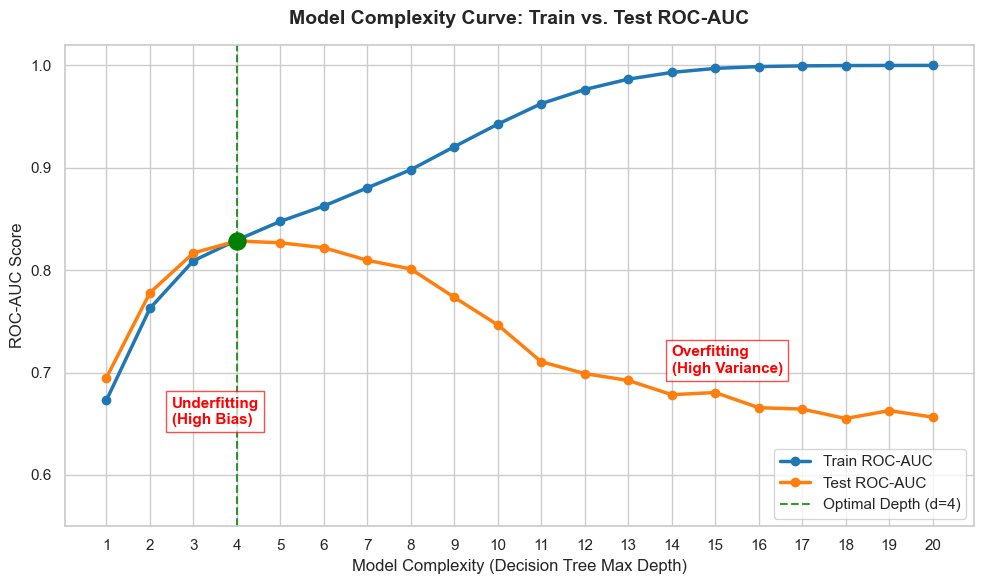

Optimal depth is d=4 with test ROC-AUC = 0.8285


In [5]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.plot(df_complexity['max_depth'], df_complexity['Train_ROC_AUC'], 'o-', label='Train ROC-AUC', color='#1f77b4', linewidth=2.5)
plt.plot(df_complexity['max_depth'], df_complexity['Test_ROC_AUC'], 'o-', label='Test ROC-AUC', color='#ff7f0e', linewidth=2.5)

# Highlight peak test performance
optimal_idx = df_complexity['Test_ROC_AUC'].idxmax()
optimal_depth = df_complexity.loc[optimal_idx, 'max_depth']
optimal_score = df_complexity.loc[optimal_idx, 'Test_ROC_AUC']

plt.axvline(x=optimal_depth, color='green', linestyle='--', alpha=0.8, label=f'Optimal Depth (d={optimal_depth})')
plt.scatter(optimal_depth, optimal_score, color='green', s=150, zorder=5)

# Annotate regimes
plt.text(2.5, 0.65, "Underfitting\n(High Bias)", color='red', fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))
plt.text(14, 0.70, "Overfitting\n(High Variance)", color='red', fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))

plt.title('Model Complexity Curve: Train vs. Test ROC-AUC', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Complexity (Decision Tree Max Depth)', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xticks(df_complexity['max_depth'])
plt.ylim(0.55, 1.02)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('complexity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Optimal depth is d={optimal_depth} with test ROC-AUC = {optimal_score:.4f}")


## Step 5: Learning Curves (Varying Training Set Size)
A **Learning Curve** plots the training and validation scores against the number of training samples. It helps us diagnose whether our model suffers from **high bias** or **high variance**, and whether collecting more data would improve performance.

We will write a helper function to plot learning curves using `sklearn.model_selection.learning_curve` with 5-fold cross-validation. We'll generate three models to compare:
1. **Underfitted Model (High Bias)**: Decision Tree with `max_depth=1`
2. **Overfitted Model (High Variance)**: Decision Tree with `max_depth=15` (deep, unrestricted tree)
3. **Optimal Model (Balanced)**: Decision Tree with `max_depth=5` (regularized, tuned)


In [6]:
def compute_learning_curve(model, X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes_abs, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, train_sizes=train_sizes, scoring='roc_auc', n_jobs=-1, random_state=42
    )
    
    return train_sizes_abs, np.mean(train_scores, axis=1), np.std(train_scores, axis=1), np.mean(test_scores, axis=1), np.std(test_scores, axis=1)

# Define the models
models = {
    'Underfitted (High Bias)\nDT (max_depth=1)': DecisionTreeClassifier(max_depth=1, random_state=42),
    'Overfitted (High Variance)\nDT (max_depth=15)': DecisionTreeClassifier(max_depth=15, random_state=42),
    'Optimal (Balanced)\nDT (max_depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42)
}

print("Computing learning curves. This will take a moment...")
start_time = time.time()

lc_data = {}
for name, clf in models.items():
    sizes, tr_mean, tr_std, val_mean, val_std = compute_learning_curve(clf, X_train_scaled, y_train)
    lc_data[name] = {
        'sizes': sizes,
        'train_mean': tr_mean,
        'train_std': tr_std,
        'val_mean': val_mean,
        'val_std': val_std
    }

print(f"Learning curves computed in {time.time() - start_time:.2f} seconds.")


Computing learning curves. This will take a moment...


Learning curves computed in 4.50 seconds.


### Visualizing Learning Curves Side-by-Side
Let's plot the training and validation learning curves for the three models to visually inspect their behavior.


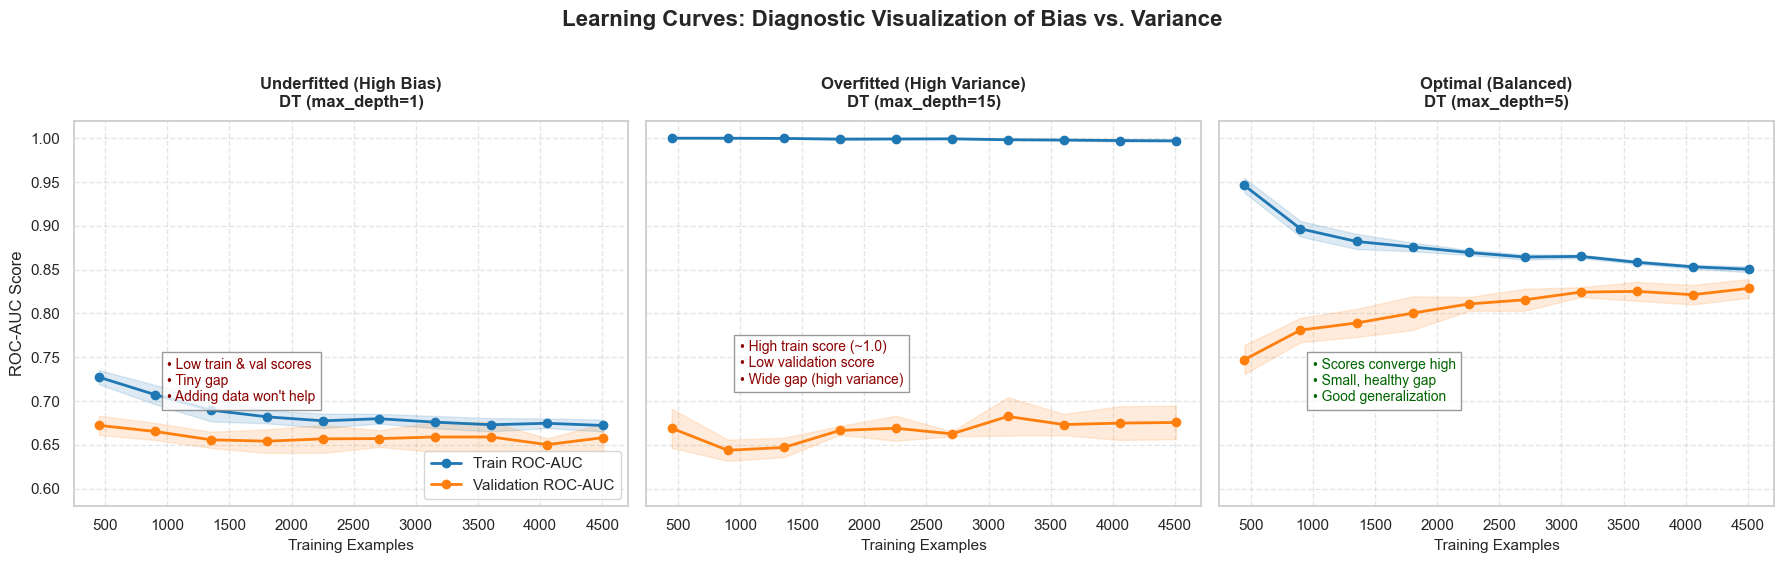

Saved learning_curves.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

colors = {
    'train': '#1f77b4',
    'val': '#ff7f0e'
}

for idx, (name, data) in enumerate(lc_data.items()):
    ax = axes[idx]
    sizes = data['sizes']
    
    # Train curve
    ax.plot(sizes, data['train_mean'], 'o-', label='Train ROC-AUC', color=colors['train'], linewidth=2)
    ax.fill_between(sizes, data['train_mean'] - data['train_std'], data['train_mean'] + data['train_std'], alpha=0.15, color=colors['train'])
    
    # Validation curve
    ax.plot(sizes, data['val_mean'], 'o-', label='Validation ROC-AUC', color=colors['val'], linewidth=2)
    ax.fill_between(sizes, data['val_mean'] - data['val_std'], data['val_mean'] + data['val_std'], alpha=0.15, color=colors['val'])
    
    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Training Examples', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Annotate behavior
    if 'Underfitted' in name:
        ax.text(1000, 0.70, "• Low train & val scores\n• Tiny gap\n• Adding data won't help", color='darkred', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    elif 'Overfitted' in name:
        ax.text(1000, 0.72, "• High train score (~1.0)\n• Low validation score\n• Wide gap (high variance)", color='darkred', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    elif 'Optimal' in name:
        ax.text(1000, 0.70, "• Scores converge high\n• Small, healthy gap\n• Good generalization", color='darkgreen', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

axes[0].set_ylabel('ROC-AUC Score', fontsize=12)
axes[0].set_ylim(0.58, 1.02)
axes[0].legend(loc='lower right', frameon=True)

plt.suptitle('Learning Curves: Diagnostic Visualization of Bias vs. Variance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved learning_curves.png")


## Step 6: Diagnostic Insights and Generalization Analysis

### 📊 Summary Table
Let's extract the final train and validation ROC-AUC scores at the maximum training sample size for all three models:


In [8]:
summary_list = []
for name, data in lc_data.items():
    summary_list.append({
        'Model Group': name.split('\n')[0],
        'Model Config': name.split('\n')[1],
        'Train ROC-AUC (Max Size)': data['train_mean'][-1],
        'Val ROC-AUC (Max Size)': data['val_mean'][-1],
        'Generalization Gap': data['train_mean'][-1] - data['val_mean'][-1]
    })

df_summary = pd.DataFrame(summary_list)
print(df_summary.round(4).to_string(index=False))


               Model Group      Model Config  Train ROC-AUC (Max Size)  Val ROC-AUC (Max Size)  Generalization Gap
   Underfitted (High Bias)  DT (max_depth=1)                    0.6722                  0.6583              0.0139
Overfitted (High Variance) DT (max_depth=15)                    0.9970                  0.6756              0.3214
        Optimal (Balanced)  DT (max_depth=5)                    0.8504                  0.8287              0.0218


### 🧠 Diagnostic Guide: Actionable Remedies
Based on today's experiments, we can construct a diagnostic checklist for ML engineers in production:

#### 1. Diagnosing High Bias (Underfitting)
* **Symptoms:** Poor performance on training data AND validation data; training score is low; learning curve shows training and validation curves converge quickly to a low value.
* **Fixes:**
  * **Increase model complexity:** Use a larger tree depth, add more layers/neurons, or switch to a more complex algorithm (e.g. Random Forest, XGBoost instead of simple Decision Trees).
  * **Add features:** Engineer new features, perform polynomial features, or decrease feature selection constraints.
  * **Reduce regularization:** Decrease L1/L2 penalty parameters, or decrease tree pruning parameters (like `min_samples_leaf` or `min_samples_split`).
  * **Note:** *Collecting more training data will NOT help here* because the model does not have the capacity to learn the pattern.

#### 2. Diagnosing High Variance (Overfitting)
* **Symptoms:** Exceptional training performance (e.g. 100% accuracy) but poor validation performance. Learning curve shows a large gap between training and validation lines.
* **Fixes:**
  * **Collect more training data:** More data helps the model generalize better and reduces the variance.
  * **Reduce model complexity:** Limit tree depth, reduce the number of features, or select a simpler model architecture.
  * **Increase regularization:** Apply L1/L2 penalties, increase tree regularization parameters (like `min_samples_leaf` or `min_samples_split`), or add dropout.
  * **Feature Selection:** Identify and drop uninformative, noisy, or highly redundant features.
